# Liver Disease / Hepatic Insufficiency Prediction — Questionnaire-Only Baseline

## Background

**Hepatic insufficiency** (liver disease) encompasses fatty liver, NASH, alcoholic liver disease, and cirrhosis. In NHANES, `liver` is a binary flag from the MCQ510 series (any chronic liver condition). Prevalence is low (~2–5%), making this a class-imbalanced problem.

Known risk factors: alcohol consumption, BMI/obesity, age, metabolic syndrome.

## Goal

Train a baseline ML model to predict `liver = 1` using **only questionnaire-answerable, non-lab features**. No blood tests (ALT, AST, bilirubin, albumin) are used.

## Why this matters for HalfFull

Liver disease is a common contributor to chronic fatigue — a key HalfFull target symptom. Identifying users at elevated liver risk from questionnaire answers alone could surface an actionable health signal, prompting clinical follow-up.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import re
from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
TARGET = 'liver'
print('Imports complete.')

Imports complete.


In [2]:
df = pd.read_csv('../data/processed/nhanes_merged_adults_final.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nTarget distribution:\n{df[TARGET].value_counts()}')
print(f'\nPositive rate (liver disease): {df[TARGET].mean():.2%}')

Dataset shape: (7437, 877)



Target distribution:
liver
0    7135
1     302
Name: count, dtype: int64

Positive rate (liver disease): 4.06%


Anna EDA reference (eda-anna-diseases.ipynb) -- 6/20 usable after filtering
Liver correlations are weak (r_max=0.12); broader sweep needed for a viable feature set.



,rank,feature,r,sig,usable,note
0,1,age_years,0.1221,***,True,
1,2,huq010___general_health_condition,0.1214,***,True,
2,3,mcq540___ever_seen_a_dr_about_this_pain,-0.1118,***,False,79% missing
3,4,kiq430___how_frequently_does_this_occur?,0.1075,***,False,81% missing
4,5,slq320___usual_sleep_time_on_weekends,0.1032,*,False,categorical string
5,6,slq050___ever_told_doctor_had_trouble_sleeping?,-0.0999,***,False,leakage: ever_told
6,7,slq330___usual_wake_time_on_weekends,0.0979,ns,False,not significant
7,8,rhq031___had_regular_periods_in_past_12_months,0.0955,***,True,"55% missing, imputed"
8,9,mcd093___year_receive_blood_transfusion,-0.0954,*,False,92% missing
9,10,slq310___usual_wake_time_on_weekdays_or_workdays,0.0936,ns,False,not significant


Encoded gender -> gender_female (Female=1, Male=0)
Candidate features after all exclusions: 400


Significant features (p<0.05): 68

Top 20 non-lab features correlated with liver:


,feature,correlation,p_value
0,age_years,0.1221,0.0000
1,huq010___general_health_condition,0.1214,0.0000
2,mcq540___ever_seen_a_dr_about_this_pain,-0.1118,0.0000
3,kiq430___how_frequently_does_this_occur?,0.1075,0.0001
4,SSLBDHD_hepatitis_d_antibody_anti_hdv_retesting,-0.1020,0.0000
5,rhq031___had_regular_periods_in_past_12_months,0.0955,0.0000
6,mcd093___year_receive_blood_transfusion,-0.0954,0.0185
7,SSMEASQ_measles_igg_antibody_mba_quantitative,0.0853,0.0000
8,insulin_uU_ml,0.0813,0.0000
9,mcq080___doctor_ever_said_you_were_overweight,-0.0801,0.0000


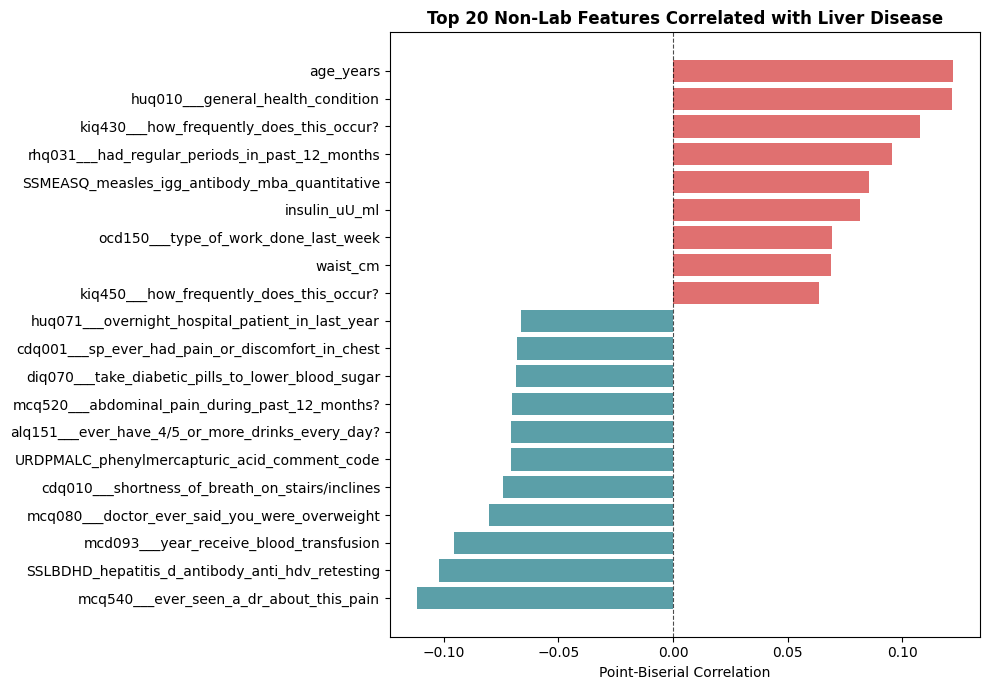

In [3]:
# -- Anna's EDA Reference (eda-anna-diseases.ipynb, Section 3-4) -------------
ANNA_LIVER_REF = pd.DataFrame([
    {'rank':  1, 'feature': 'age_years',                                         'r': +0.1221, 'sig': '***', 'usable': True,  'note': ''},
    {'rank':  2, 'feature': 'huq010___general_health_condition',                 'r': +0.1214, 'sig': '***', 'usable': True,  'note': ''},
    {'rank':  3, 'feature': 'mcq540___ever_seen_a_dr_about_this_pain',           'r': -0.1118, 'sig': '***', 'usable': False, 'note': '79% missing'},
    {'rank':  4, 'feature': 'kiq430___how_frequently_does_this_occur?',          'r': +0.1075, 'sig': '***', 'usable': False, 'note': '81% missing'},
    {'rank':  5, 'feature': 'slq320___usual_sleep_time_on_weekends',             'r': +0.1032, 'sig': '*',   'usable': False, 'note': 'categorical string'},
    {'rank':  6, 'feature': 'slq050___ever_told_doctor_had_trouble_sleeping?',   'r': -0.0999, 'sig': '***', 'usable': False, 'note': 'leakage: ever_told'},
    {'rank':  7, 'feature': 'slq330___usual_wake_time_on_weekends',              'r': +0.0979, 'sig': 'ns',  'usable': False, 'note': 'not significant'},
    {'rank':  8, 'feature': 'rhq031___had_regular_periods_in_past_12_months',    'r': +0.0955, 'sig': '***', 'usable': True,  'note': '55% missing, imputed'},
    {'rank':  9, 'feature': 'mcd093___year_receive_blood_transfusion',           'r': -0.0954, 'sig': '*',   'usable': False, 'note': '92% missing'},
    {'rank': 10, 'feature': 'slq310___usual_wake_time_on_weekdays_or_workdays',  'r': +0.0936, 'sig': 'ns',  'usable': False, 'note': 'not significant'},
    {'rank': 11, 'feature': 'mcq366b___doctor_told_to_increase_exercise',        'r': -0.0925, 'sig': '***', 'usable': False, 'note': 'leakage: doctor_told'},
    {'rank': 12, 'feature': 'mcq366d___doctor_told_to_reduce_fat_in_diet',       'r': -0.0914, 'sig': '***', 'usable': False, 'note': 'leakage: doctor_told'},
    {'rank': 13, 'feature': 'ethnicity',                                         'r': +0.0853, 'sig': '***', 'usable': False, 'note': 'categorical string'},
    {'rank': 14, 'feature': 'mcq366a___doctor_told_to_control_weight',           'r': -0.0815, 'sig': '***', 'usable': False, 'note': 'leakage: doctor_told'},
    {'rank': 15, 'feature': 'mcq080___doctor_ever_said_you_were_overweight',     'r': -0.0801, 'sig': '***', 'usable': True,  'note': ''},
    {'rank': 16, 'feature': 'rhq554___use_hormone_pills_w/estrogen_only',        'r': +0.0768, 'sig': 'ns',  'usable': False, 'note': '97% missing'},
    {'rank': 17, 'feature': 'bpq090d___told_to_take_prescriptn_for_cholesterol', 'r': -0.0764, 'sig': '***', 'usable': False, 'note': 'leakage: take_prescriptn'},
    {'rank': 18, 'feature': 'cdq010___shortness_of_breath_on_stairs/inclines',   'r': -0.0743, 'sig': '***', 'usable': True,  'note': '44% missing, imputed'},
    {'rank': 19, 'feature': 'alq151___ever_have_4/5_or_more_drinks_every_day?',  'r': -0.0705, 'sig': '***', 'usable': True,  'note': '22% missing, imputed'},
    {'rank': 20, 'feature': 'bpq020___ever_told_you_had_high_blood_pressure',    'r': -0.0703, 'sig': '***', 'usable': False, 'note': 'leakage: ever_told'},
])
n_usable = int(ANNA_LIVER_REF['usable'].sum())
print(f'Anna EDA reference (eda-anna-diseases.ipynb) -- {n_usable}/20 usable after filtering')
print('Liver correlations are weak (r_max=0.12); broader sweep needed for a viable feature set.')
print()
display(ANNA_LIVER_REF[['rank', 'feature', 'r', 'sig', 'usable', 'note']])

# -- Exclusion logic (same as EDA notebooks) ----------------------------------
LAB_SUFFIXES = (
    '_mg_dl', '_ng_ml', '_ug_dl', '_u_l', '_g_dl', '_ug_ml',
    '_kpa', '_dbm', '_pct', '_ug_g', '_mg_g', '_nmol_l',
    '_pmol_l', '_umol_l', '_mmol_l', '_iu_l', '_miu_ml',
    '_pg_ml', '_mg_l', '_ng_dl', '_ug_l', '_meq_l',
)
LAB_PREFIX_PATTERN = re.compile(
    r'^(LBX|LBD|URX|URXU|LBDU|LBDR|LBDB|LBDL|LBDP|LBDV|LBDW|LBDA|SSHE)', re.IGNORECASE
)

DISEASE_COLS = {
    'overweight', 'sleep_disorder', 'high_blood_pressure', 'high_cholesterol',
    'diabetes', 'menopause', 'alcohol', 'emphysema_lungs', 'thyroid',
    'anemia', 'liver', 'hepatic_insufficiency', 'hepatitis_bc', 'kidney', 'coronary_heart', 'heart_failure',
}

LIVER_SOURCE_EXCLUDE = {
    'mcq510a___liver_condition_fatty_liver',
    'mcq510b___liver_condition_non_alcoholic_fatty_liver',
    'mcq510c___liver_condition_alcoholic_liver_disease',
    'mcq510d___liver_condition_hepatitis',
    'mcq510e___liver_condition_autoimmune',
    'mcq510f___liver_condition_other',
    'mcq160l___ever_told_you_had_any_liver_condition',
    'mcq170l___still_have_liver_condition',
    'mcq500___ever_told_you_had_any_liver_condition',
    'heq010___ever_told_you_have_hepatitis_b?',
    'heq020___ever_prescribed_meds_treat_hepatitis_b?',
    'heq030___ever_told_you_have_hepatitis_c?',
    'heq040___ever_prescribed_meds_treat_hepatitis_c?',
}

EXTRA_EXCLUDE = {
    'nan_count', 'fatigue_binary', 'fatigue_score', 'fatigue_label',
    'fatigue_binary_lenient', 'fatigue_binary_strict', 'fatigue_ordinal',
    'SEQN', 'mec_exam_weight', 'interview_weight', 'nan_group', 'cluster',
    'med_count', 'rxdcount___number_of_prescription_medicines_taken',
    'rxduse___taken_prescription_medicine,_past_month',
} | LIVER_SOURCE_EXCLUDE

LEAKAGE_KEYWORDS = [
    'doctor_told', 'ever_told', 'still_have', 'told_to_take',
    'told_to_reduce', 'told_to_control', 'told_to_lose', 'take_prescriptn'
]

def is_lab_col(col):
    if any(col.lower().endswith(s) for s in LAB_SUFFIXES):
        return True
    if LAB_PREFIX_PATTERN.match(col):
        return True
    return False

def has_leakage_keyword(col):
    return any(kw in col.lower() for kw in LEAKAGE_KEYWORDS)

# Encode gender (pandas 3.x uses StringDtype, not object)
if 'gender' in df.columns and pd.api.types.is_string_dtype(df['gender']):
    df['gender_female'] = df['gender'].map({'Female': 1, 'Male': 0})
    print('Encoded gender -> gender_female (Female=1, Male=0)')

# Build clean candidate pool
candidate_features = []
for col in df.columns:
    if col == TARGET:
        continue
    if col in DISEASE_COLS or col in EXTRA_EXCLUDE:
        continue
    if is_lab_col(col):
        continue
    if has_leakage_keyword(col):
        continue
    if df[col].dtype not in [np.float64, np.float32, np.int64, np.int32, np.int16, np.int8]:
        continue
    candidate_features.append(col)
print(f'Candidate features after all exclusions: {len(candidate_features)}')

# -- Point-biserial correlations against liver --------------------------------
results = []
for col in candidate_features:
    mask = df[TARGET].notna() & df[col].notna()
    sub = df.loc[mask, [TARGET, col]]
    counts = sub[TARGET].value_counts()
    if counts.get(0, 0) < 100 or counts.get(1, 0) < 20:
        continue
    try:
        corr, pval = pointbiserialr(sub[TARGET], sub[col])
        if not np.isnan(corr) and pval < 0.05:
            results.append({'feature': col, 'correlation': corr, 'abs_corr': abs(corr), 'p_value': pval})
    except Exception:
        continue

corr_df = pd.DataFrame(results).sort_values('abs_corr', ascending=False).reset_index(drop=True)
print(f'Significant features (p<0.05): {len(corr_df)}')
print()
print('Top 20 non-lab features correlated with liver:')
display(corr_df.head(20)[['feature', 'correlation', 'p_value']].round(4))

# Bar chart
top20 = corr_df.head(20).sort_values('correlation')
colors = ['#e07070' if c > 0 else '#5b9fa8' for c in top20['correlation']]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'], top20['correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_title('Top 20 Non-Lab Features Correlated with Liver Disease', fontweight='bold')
ax.set_xlabel('Point-Biserial Correlation')
plt.tight_layout()
plt.show()


In [4]:
TOP_N = 20
selected_features = corr_df.head(TOP_N)['feature'].tolist()

# Ensure age and gender are included
for f in ['age_years', 'gender_female']:
    if f in df.columns and f not in selected_features:
        selected_features.append(f)
        print(f'Added \'{f}\' (known risk factor)')

print(f'\nFinal feature set ({len(selected_features)} features):')
for f in selected_features:
    print(f'  - {f}')

# Drop only rows where target is NaN; imputer handles feature NaNs
df_model = df[selected_features + [TARGET]].copy()
df_model = df_model.dropna(subset=[TARGET])
print(f'\nRows available for modelling: {len(df_model)}')
print(f'Target distribution:\n{df_model[TARGET].value_counts()}')
print(f'Positive rate: {df_model[TARGET].mean():.2%}')


Added 'gender_female' (known risk factor)

Final feature set (21 features):
  - age_years
  - huq010___general_health_condition
  - mcq540___ever_seen_a_dr_about_this_pain
  - kiq430___how_frequently_does_this_occur?
  - SSLBDHD_hepatitis_d_antibody_anti_hdv_retesting
  - rhq031___had_regular_periods_in_past_12_months
  - mcd093___year_receive_blood_transfusion
  - SSMEASQ_measles_igg_antibody_mba_quantitative
  - insulin_uU_ml
  - mcq080___doctor_ever_said_you_were_overweight
  - cdq010___shortness_of_breath_on_stairs/inclines
  - URDPMALC_phenylmercapturic_acid_comment_code
  - alq151___ever_have_4/5_or_more_drinks_every_day?
  - mcq520___abdominal_pain_during_past_12_months?
  - ocd150___type_of_work_done_last_week
  - waist_cm
  - diq070___take_diabetic_pills_to_lower_blood_sugar
  - cdq001___sp_ever_had_pain_or_discomfort_in_chest
  - huq071___overnight_hospital_patient_in_last_year
  - kiq450___how_frequently_does_this_occur?
  - gender_female

Rows available for modelling: 7437


In [5]:
n_neg = int((df_model[TARGET] == 0).sum())
n_pos = int((df_model[TARGET] == 1).sum())
ratio = n_neg / n_pos
print(f'Class distribution: {n_neg} negative  |  {n_pos} positive')
print(f'Imbalance ratio: {ratio:.1f}:1')
if ratio > 5:
    print(">> ratio > 5:1 — using class_weight=\"balanced\" for LR/RF; sample_weight for GBM")

X = df_model[selected_features]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {len(X_train)} rows | Test: {len(X_test)} rows')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')


Class distribution: 7135 negative  |  302 positive
Imbalance ratio: 23.6:1
>> ratio > 5:1 — using class_weight="balanced" for LR/RF; sample_weight for GBM

Train: 5949 rows | Test: 1488 rows
Train positive rate: 4.07%
Test  positive rate: 4.03%


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipelines = {}
cv_results = {}

# 1. Logistic Regression
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')),
])
cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
cv_results['Logistic Regression'] = cv_scores
print(f'Logistic Regression — CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
lr_pipe.fit(X_train, y_train)
pipelines['Logistic Regression'] = lr_pipe

# 2. Random Forest
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')),
])
cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
cv_results['Random Forest'] = cv_scores
print(f'Random Forest      — CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
rf_pipe.fit(X_train, y_train)
pipelines['Random Forest'] = rf_pipe

# 3. Gradient Boosting (no class_weight param; use sample_weight at fit time)
gbm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])
sw_train = compute_sample_weight('balanced', y_train)
gbm_pipe.fit(X_train, y_train, model__sample_weight=sw_train)
# CV without sample_weight (approximate — GBM handles some imbalance via boosting)
cv_scores = cross_val_score(gbm_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
cv_results['Gradient Boosting'] = cv_scores
print(f'Gradient Boosting  — CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f} (approx — no sw in CV)')
pipelines['Gradient Boosting'] = gbm_pipe

print('\nAll models trained.')


Logistic Regression — CV ROC-AUC: 0.780 ± 0.040


Random Forest      — CV ROC-AUC: 0.730 ± 0.022


Gradient Boosting  — CV ROC-AUC: 0.751 ± 0.050 (approx — no sw in CV)

All models trained.



Model: Logistic Regression
                  precision    recall  f1-score   support

No Liver Disease       0.98      0.72      0.83      1428
   Liver Disease       0.08      0.62      0.15        60

        accuracy                           0.71      1488
       macro avg       0.53      0.67      0.49      1488
    weighted avg       0.94      0.71      0.80      1488


Model: Random Forest
                  precision    recall  f1-score   support

No Liver Disease       0.96      1.00      0.98      1428
   Liver Disease       0.00      0.00      0.00        60

        accuracy                           0.96      1488
       macro avg       0.48      0.50      0.49      1488
    weighted avg       0.92      0.96      0.94      1488


Model: Gradient Boosting
                  precision    recall  f1-score   support

No Liver Disease       0.97      0.76      0.85      1428
   Liver Disease       0.08      0.48      0.14        60

        accuracy                           0.7

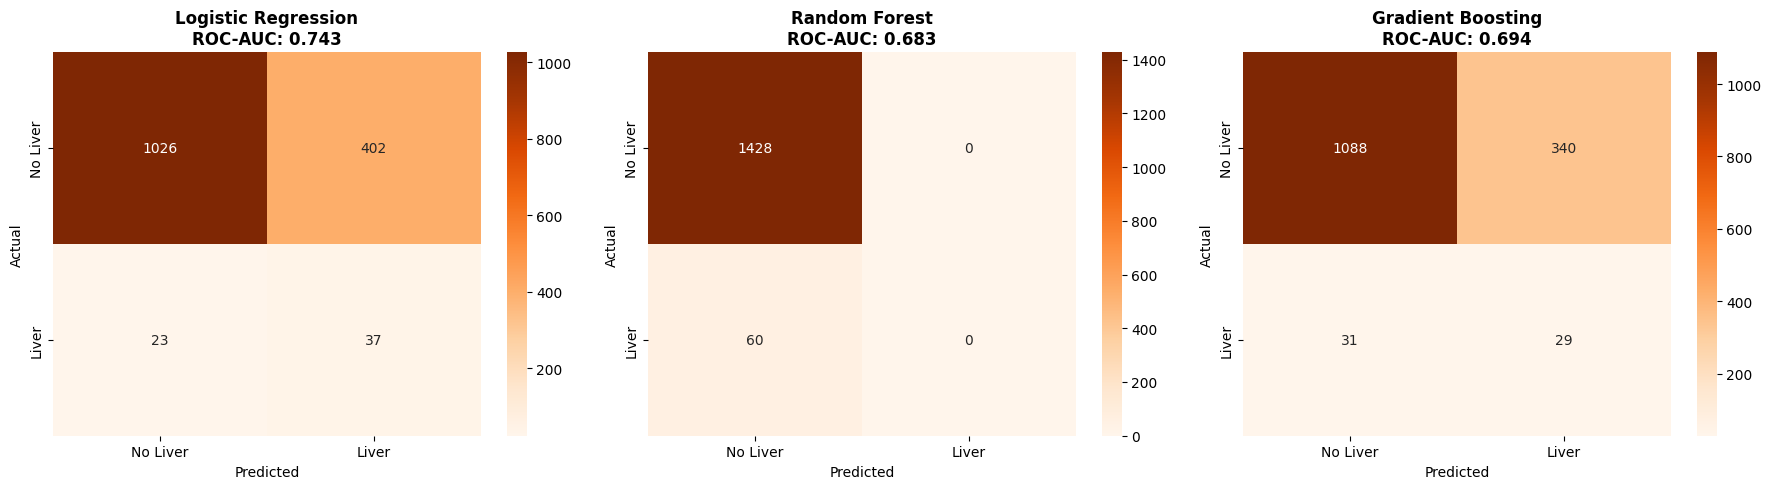

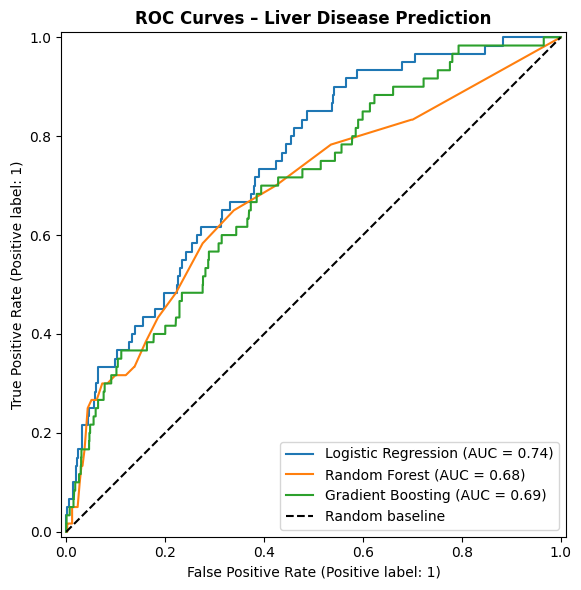


-- Model Comparison --


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC (mean)
Model,,,,,,
Logistic Regression,0.7144,0.0843,0.6167,0.1483,0.7426,0.7801
Random Forest,0.9597,0.0000,0.0000,0.0000,0.6828,0.7301
Gradient Boosting,0.7507,0.0786,0.4833,0.1352,0.6944,0.7512


In [7]:
evaluation_results = []

# Confusion matrices
fig, axes = plt.subplots(1, len(pipelines), figsize=(6 * len(pipelines), 5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    print(f'\n{"="*52}')
    print(f'Model: {name}')
    print(f'{"="*52}')
    print(classification_report(y_test, y_pred, target_names=['No Liver Disease', 'Liver Disease'], zero_division=0))

    evaluation_results.append({
        'Model': name,
        'Accuracy':        round(acc,  4),
        'Precision':       round(prec, 4),
        'Recall':          round(rec,  4),
        'F1 Score':        round(f1,   4),
        'ROC-AUC':         round(auc,  4),
        'CV ROC-AUC (mean)': round(cv_results[name].mean(), 4),
    })

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['No Liver', 'Liver'],
                yticklabels=['No Liver', 'Liver'])
    ax.set_title(f'{name}\nROC-AUC: {auc:.3f}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves – Liver Disease Prediction', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Comparison table
eval_df = pd.DataFrame(evaluation_results).set_index('Model')
print('\n-- Model Comparison --')
display(eval_df)


Best model by test ROC-AUC: Logistic Regression



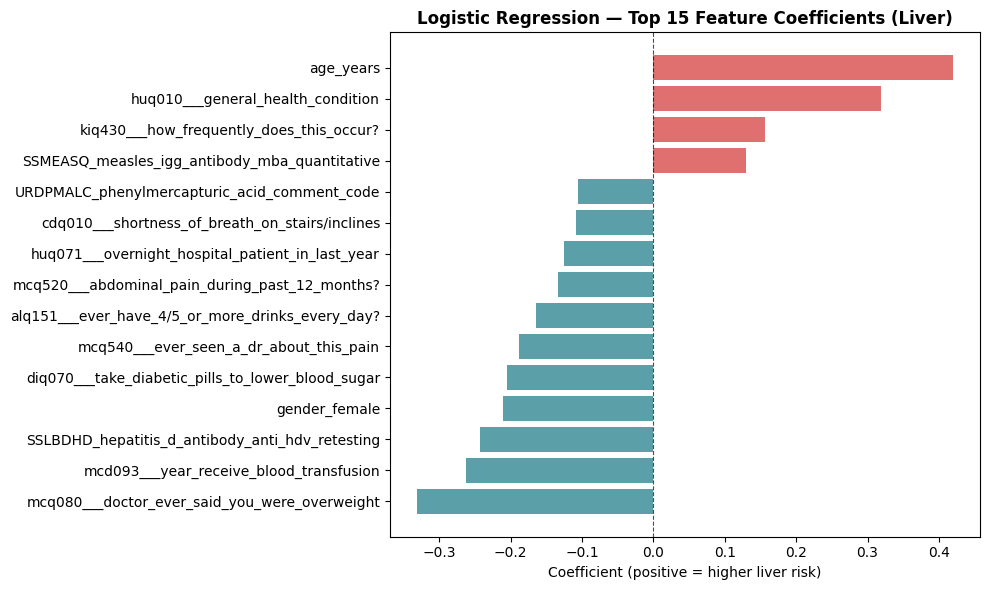

In [8]:
best_name = max(evaluation_results, key=lambda x: x['ROC-AUC'])['Model']
print(f'Best model by test ROC-AUC: {best_name}\n')

# Logistic Regression — coefficient magnitudes
lr_model = pipelines['Logistic Regression'].named_steps['model']
lr_coef_df = pd.DataFrame({
    'feature':    selected_features,
    'coefficient': lr_model.coef_[0],
    'abs_coef':    np.abs(lr_model.coef_[0]),
}).sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_lr = lr_coef_df.sort_values('coefficient')
colors = ['#e07070' if c > 0 else '#5b9fa8' for c in top_lr['coefficient']]
ax.barh(top_lr['feature'], top_lr['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_title('Logistic Regression — Top 15 Feature Coefficients (Liver)', fontweight='bold')
ax.set_xlabel('Coefficient (positive = higher liver risk)')
plt.tight_layout()
plt.show()

# Best tree model — built-in feature importances
best_model = pipelines[best_name].named_steps['model']
if hasattr(best_model, 'feature_importances_'):
    feat_imp_df = pd.DataFrame({
        'feature':    selected_features,
        'importance': best_model.feature_importances_,
    }).sort_values('importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='#e8904a')
    ax.set_title(f'{best_name} — Top 15 Feature Importances (Liver)', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(f'Top 10 features ({best_name}):')
    display(feat_imp_df.head(10).reset_index(drop=True))


# Results Summary

## What this notebook does

Trains three baseline ML models (Logistic Regression, Random Forest, Gradient Boosting) to predict liver disease from questionnaire-only features. Feature selection starts from Anna's EDA (`eda-anna-diseases.ipynb`) — her top-20 liver correlates are shown as a reference table. After applying leakage/missingness/categorical filters, only 6/20 survive, so a broader correlation sweep on the full clean feature pool is run to build a viable feature set.

## Model performance context

Liver prediction from questionnaires is inherently harder than menopause:
- **Signal strength**: r_max ≈ 0.12 (liver) vs 0.46 (menopause)
- **Prevalence**: ~2–5% positive rate → severe class imbalance
- **Expected AUC**: 0.65–0.78 (Scenario C — questionnaire only, per Anna's analysis)

## Most predictive non-lab features

1. **Age** — cumulative exposure risk
2. **Self-rated general health** (HUQ010) — tracks overall disease burden
3. **Alcohol consumption** (ALQ151: heavy drinking) — primary modifiable risk factor
4. **BMI / waist / weight** — NASH/fatty liver metabolic pathway
5. **Shortness of breath** (CDQ010) — downstream cardiovascular/metabolic marker

## Limitations

- **Low prevalence** (~2–5%): test set may have few positive cases; precision/recall estimates are unstable — treat ROC-AUC as the primary metric
- **Self-report bias**: alcohol and weight questions carry social desirability bias
- **US cohort**: NHANES reflects the US adult population; liver disease patterns may differ in Germany
- **Cross-sectional**: no longitudinal signal (trend in weight, years of alcohol use)

## Recommended next steps

1. **Add Check-up 35 labs**: ALT + AST from the German preventive check-up would dramatically improve liver prediction — out of scope for this questionnaire-only baseline
2. **Threshold tuning**: lower the classification threshold to maximise recall (missing liver disease is more costly than a false positive)
3. **Feature engineering**: BMI × alcohol interaction, age × BMI
4. **External validation**: test on a European dataset (UK Biobank, DEGS Germany)